In [1]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
import sys
import pickle

sys.path.insert(0, "../../utils")

from modules import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, log_loss, mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

enc = 'utf-8'

In [2]:
dataframe = pd.read_csv(f'../../data/Nord/CM_Nord_Dataset_2015-2024.csv', encoding=enc)

In [3]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [4]:
dataframe.drop(columns=['Case_UND5', 'Case_OVR5', 'Case_PRGN', 
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_TOTAL': 'cases'}, inplace=True)

In [5]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [6]:
dataframe.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(nord, benoue, bibemi, adoumri)",13.770202,9.240232,2014-10,-0.866,0.5,0.542311,0.148177,-0.365296,-0.148177,...,26.83,1888.0,489.0,2.0,108.60,1224.0,24.0,243.0,1224.0,106
1,"(nord, benoue, bibemi, bibemi)",13.949181,9.263633,2014-10,-0.866,0.5,0.499024,0.112709,-0.351063,-0.112709,...,25.50,1905.0,544.0,1.0,113.49,1283.0,20.0,247.0,1283.0,85
2,"(nord, benoue, bibemi, bide)",13.972945,9.422292,2014-10,-0.866,0.5,0.491692,0.119406,-0.338767,-0.119406,...,26.00,1732.0,513.0,0.0,119.68,1209.0,4.0,46.0,1209.0,30
3,"(nord, benoue, bibemi, dengui)",13.642496,9.235656,2014-10,-0.866,0.5,0.511243,0.171523,-0.300408,-0.171523,...,27.33,1922.0,503.0,3.0,105.80,1210.0,24.0,271.0,1210.0,43
4,"(nord, benoue, bibemi, djaloumi)",13.994667,9.585190,2014-10,-0.866,0.5,0.505574,0.198941,-0.280563,-0.198941,...,26.67,1725.0,471.0,0.0,117.97,1200.0,5.0,194.0,1200.0,29


In [7]:
bin_ranges = [0, 
              1,
              #2,
              #4, 
              8, 
              16, 
              32, 
              64, 
              128, 
              256, 
              512, 
              1024, 
              #2048, 
              #4096, 
              8192]

In [8]:
risk_classes = list(range(0,10))
risk_classes

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [9]:
bins, bounds = pd.cut(x = dataframe.loc[:, 'cases'], bins=bin_ranges, right=False, include_lowest=True, labels=risk_classes, retbins=True, precision=0)

In [10]:
dataframe['case_bin'] = bins

In [11]:
# dataset = pd.concat([data_0, data_rest])

dataset = dataframe.copy()

In [12]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [13]:
# bounds = np.concatenate(([0], bounds))
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    1    8   16   32   64  128  256  512 1024 8192]


In [14]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

[Text(0, 0, '0'),
 Text(1, 0, '[1-8]'),
 Text(2, 0, '(8-16]'),
 Text(3, 0, '(16-32]'),
 Text(4, 0, '(32-64]'),
 Text(5, 0, '(64-128]'),
 Text(6, 0, '(128-256]'),
 Text(7, 0, '(256-512]'),
 Text(8, 0, '(512-1024]'),
 Text(9, 0, '1024+')]

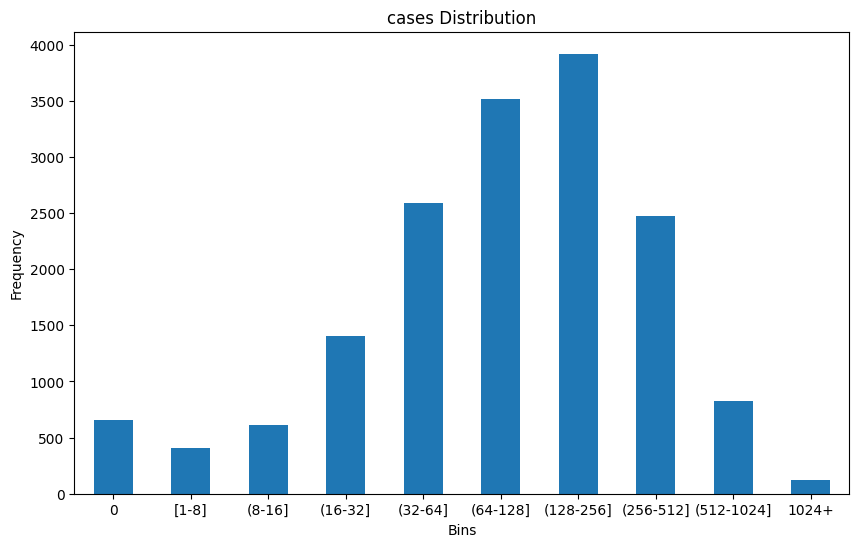

In [15]:
target_col = 'cases'

ax = dataset['case_bin'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10, 6),
    title=f'{target_col} Distribution',
    xlabel='Bins',
    ylabel='Frequency'
)

# Set custom x-axis tick labels
ax.set_xticklabels(['0', '[1-8]', '(8-16]', '(16-32]','(32-64]','(64-128]','(128-256]','(256-512]','(512-1024]','1024+'], rotation=0) 
        

In [16]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases,case_bin
0,"(nord, benoue, bibemi, adoumri)",13.770202,9.240232,2014-10,-0.866,0.5,0.542311,0.148177,-0.365296,-0.148177,...,1888.0,489.0,2.0,108.60,1224.0,24.0,243.0,1224.0,106,5
1,"(nord, benoue, bibemi, bibemi)",13.949181,9.263633,2014-10,-0.866,0.5,0.499024,0.112709,-0.351063,-0.112709,...,1905.0,544.0,1.0,113.49,1283.0,20.0,247.0,1283.0,85,5
2,"(nord, benoue, bibemi, bide)",13.972945,9.422292,2014-10,-0.866,0.5,0.491692,0.119406,-0.338767,-0.119406,...,1732.0,513.0,0.0,119.68,1209.0,4.0,46.0,1209.0,30,3
3,"(nord, benoue, bibemi, dengui)",13.642496,9.235656,2014-10,-0.866,0.5,0.511243,0.171523,-0.300408,-0.171523,...,1922.0,503.0,3.0,105.80,1210.0,24.0,271.0,1210.0,43,4
4,"(nord, benoue, bibemi, djaloumi)",13.994667,9.585190,2014-10,-0.866,0.5,0.505574,0.198941,-0.280563,-0.198941,...,1725.0,471.0,0.0,117.97,1200.0,5.0,194.0,1200.0,29,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16518,"(nord, mayo-rey, touboro, mbeing)",15.001895,7.650008,2024-06,0.000,-1.0,0.513966,0.190414,-0.397487,-0.190414,...,2746.0,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0,66,5
16519,"(nord, mayo-rey, touboro, ngai-lara)",15.110765,7.963850,2024-06,0.000,-1.0,0.402476,0.101305,-0.347630,-0.101305,...,2791.0,626.0,0.0,97.38,1598.0,0.0,175.0,1598.0,140,6
16520,"(nord, mayo-rey, touboro, touboro)",15.293957,7.759324,2024-06,0.000,-1.0,0.450903,0.092213,-0.381622,-0.092213,...,2842.0,589.0,0.0,94.80,1630.0,2.0,462.0,1630.0,708,8
16521,"(nord, mayo-rey, touboro, vogzom)",14.714359,7.747549,2024-06,0.000,-1.0,0.454325,0.093292,-0.384450,-0.093292,...,2527.0,490.0,0.0,93.43,1316.0,0.0,163.0,1316.0,408,7


In [17]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['cases', 'case_bin'])
y = dataset['case_bin']

n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [18]:
features_to_remove = []

feature_names = X.drop(columns = features_to_remove).columns
print(feature_names.to_list())

print(f"Total Features Used: {len(feature_names)}")

['x', 'y', 'month_sin', 'month_cos', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_min_prev_month', 'lst_max_prev_month', 'rainfall', 'rainfall_acc_prev_month', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19']
Total Features Used: 66


In [19]:
with open("CM_Nord_rfecv_model.pkl", "rb") as f:
    fitted_rfe = pickle.load(f)

In [22]:
model_params = {
    'objective': 'reg:squarederror',
    'max_depth': 7,
    'learning_rate': 0.1,
    'n_estimators': 250, 
    'min_child_weight': 2,
    'gamma': 0,
    'random_state': 0
}

In [23]:
fold_counter = 0
n_models = 10 

y_true_list = []
y_pred_list = []
y_index_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    imputer = KNNImputer(n_neighbors=3)
    imputer.fit(X_train_scaled)
    X_train_imputed = pd.DataFrame(imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

    X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
    X_test_imputed = pd.DataFrame(scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

    X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)
    X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

    X_train_rfe = pd.DataFrame(fitted_rfe.transform(X_train_imputed), columns = X.columns[fitted_rfe.support_], index=X_train.index)
    X_test_rfe = pd.DataFrame(fitted_rfe.transform(X_test_imputed), columns = X.columns[fitted_rfe.support_], index=X_test.index)

    ## --- Ensemble Model Training ---
    y_pred_ensemble_list = []

    for model in range(n_models):
        print(f"\tEnsemble Model {model+1}/{n_models}", end='\r')
        ensemble_params = model_params.copy()
        ensemble_params['subsample'] = 0.8
        ensemble_params['colsample_bytree'] = 0.8
        ensemble_params['seed'] = model * 100 + fold_counter

        model = xgb.XGBRegressor(**ensemble_params)   
        fitted_model = model.fit(X_train_rfe, y_train, verbose=False)

        y_pred = fitted_model.predict(X_test_rfe)

        y_pred_ensemble_list.append(y_pred)

    y_true_list.append(y_test)
    y_pred_list.append(y_pred_ensemble_list)
    y_index_list.append(test_idx)

    fold_counter += 1
    print('\n', end='\r')

Fold: 1/10
	Ensemble Model 10/10
Fold: 2/10
	Ensemble Model 10/10
Fold: 3/10
	Ensemble Model 10/10
Fold: 4/10
	Ensemble Model 10/10
Fold: 5/10
	Ensemble Model 10/10
Fold: 6/10
	Ensemble Model 10/10
Fold: 7/10
	Ensemble Model 10/10
Fold: 8/10
	Ensemble Model 10/10
Fold: 9/10
	Ensemble Model 10/10
Fold: 10/10
	Ensemble Model 10/10


In [24]:
y_true = np.concatenate(y_true_list, axis=0)
y_preds = [np.column_stack(pred) for pred in y_pred_list]
y_pred = np.vstack(y_preds)
# y_pred = np.clip(np.round(y_pred), 0, 9).astype(int)
y_pred = np.clip(y_pred, 0, 9)
y_index = np.concatenate(y_index_list, axis=0)

In [25]:
ens_columns = [f"ens_{i+1}" for i in range(y_pred.shape[1])]

df_ensembles = pd.DataFrame(
    data=y_pred,
    index=y_index,
    columns=ens_columns
)

df_ensembles['y_true'] = y_true
df_ensembles.sort_index(inplace=True)

In [26]:
# Mean prediction (ensemble average)
df_ensembles['y_pred_mean'] = df_ensembles[ens_columns].mean(axis=1)

# Uncertainty (std dev of ensemble predictions)
df_ensembles['y_uncertainty'] = df_ensembles[ens_columns].std(axis=1)

In [27]:
from scipy.stats import norm

z = norm.ppf(0.975)  # ~1.96

df_ensembles['pred_lower'] = df_ensembles['y_pred_mean'] - z * df_ensembles['y_uncertainty']
df_ensembles['pred_upper'] = df_ensembles['y_pred_mean'] + z * df_ensembles['y_uncertainty']

In [28]:
df_ensembles

,ens_1,ens_2,ens_3,ens_4,ens_5,ens_6,ens_7,ens_8,ens_9,ens_10,y_true,y_pred_mean,y_uncertainty,pred_lower,pred_upper
0,4.627248,4.704382,4.755946,4.732417,4.828797,4.847567,4.911988,5.104149,5.119724,5.133089,5,4.876531,0.185063,4.513813,5.239248
1,5.121742,5.222517,5.392420,4.783669,5.089791,5.461659,5.029188,5.062306,4.690500,5.063690,5,5.091748,0.237281,4.626685,5.556811
2,2.891854,2.999834,3.141392,3.317823,3.009937,3.358353,2.770730,2.668504,3.655650,2.703850,3,3.051793,0.318752,2.427050,3.676535
3,2.924372,2.906153,2.390915,2.340248,2.687622,2.496261,2.497942,3.169353,2.684844,2.653044,4,2.675075,0.261789,2.161978,3.188173
4,2.923815,3.700846,3.238874,2.763016,3.518757,3.205654,3.387350,3.188443,3.324787,3.128370,3,3.237991,0.271361,2.706133,3.769850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16518,5.018393,5.216352,4.832464,4.933265,5.008737,4.930241,4.833636,5.209741,5.035456,5.040757,5,5.005904,0.132853,4.745517,5.266291
16519,5.777338,5.897810,5.921907,5.935351,5.744597,5.755698,5.657714,5.805947,5.910163,5.990947,6,5.839747,0.106130,5.631736,6.047759
16520,7.008477,6.843338,7.352196,7.122209,6.837820,7.212523,7.036893,7.113326,7.201376,7.358936,8,7.108709,0.182719,6.750587,7.466831
16521,6.298656,6.629808,6.380929,6.324573,6.171882,6.465679,6.687902,6.090439,6.196546,6.518946,7,6.376536,0.198393,5.987692,6.765379


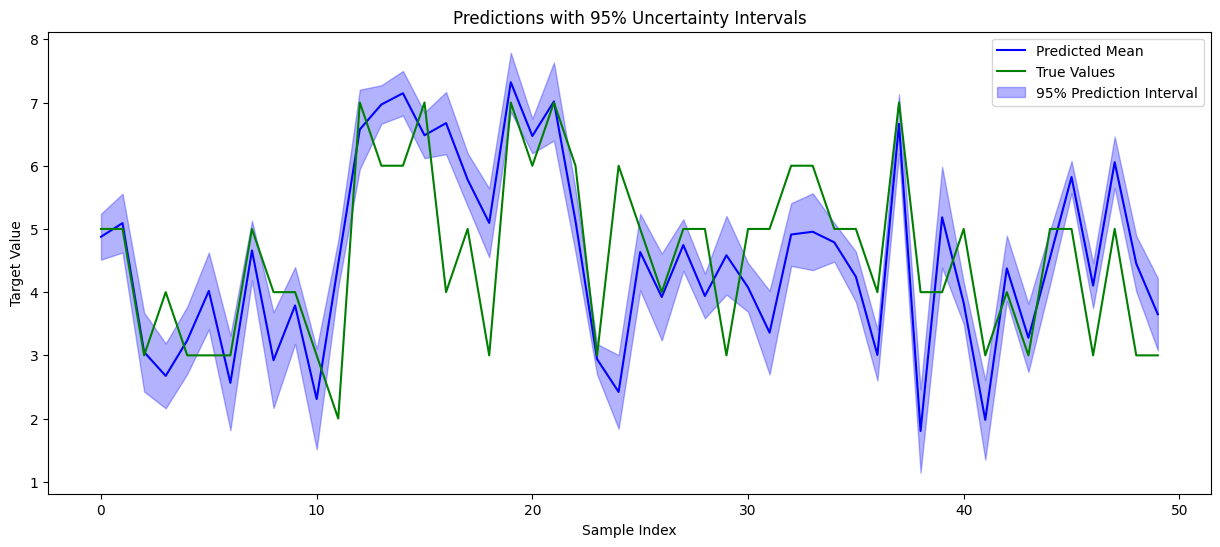

In [29]:
import matplotlib.pyplot as plt

# Select a subset (e.g., first 100 samples) to keep plot clear
subset = df_ensembles.iloc[:50]

plt.figure(figsize=(15,6))

# Plot mean prediction
plt.plot(subset.index, subset["y_pred_mean"], label="Predicted Mean", color="blue")

# Plot ground truth
plt.plot(subset.index, subset["y_true"], label="True Values", color="green")

# Fill between prediction intervals
plt.fill_between(
    subset.index,
    subset["pred_lower"],
    subset["pred_upper"],
    color="blue",
    alpha=0.3,
    label="95% Prediction Interval"
)

plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.title("Predictions with 95% Uncertainty Intervals")
plt.legend()
plt.show()

In [30]:
df_ensembles_sorted = df_ensembles.sort_values(by='y_pred_mean').reset_index(drop=True)

In [31]:
df_ensembles_sorted.head()

,ens_1,ens_2,ens_3,ens_4,ens_5,ens_6,ens_7,ens_8,ens_9,ens_10,y_true,y_pred_mean,y_uncertainty,pred_lower,pred_upper
0,0.000000,0.000000,0.000000,0.045743,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0,0.004574,0.014465,-0.023777,0.032926
1,0.000000,0.357258,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0,0.035726,0.112975,-0.185701,0.257152
2,0.134073,0.000000,0.000000,0.097224,0.000000,0.0,0.228053,0.000000,0.0,0.000000,0,0.045935,0.080509,-0.111861,0.203730
3,0.000000,0.000000,0.000000,0.372777,0.000000,0.0,0.000000,0.087005,0.0,0.000000,2,0.045978,0.118036,-0.185368,0.277324
4,0.000000,0.000000,0.132747,0.075901,0.260143,0.0,0.000000,0.000000,0.0,0.233173,0,0.070196,0.103361,-0.132388,0.272780


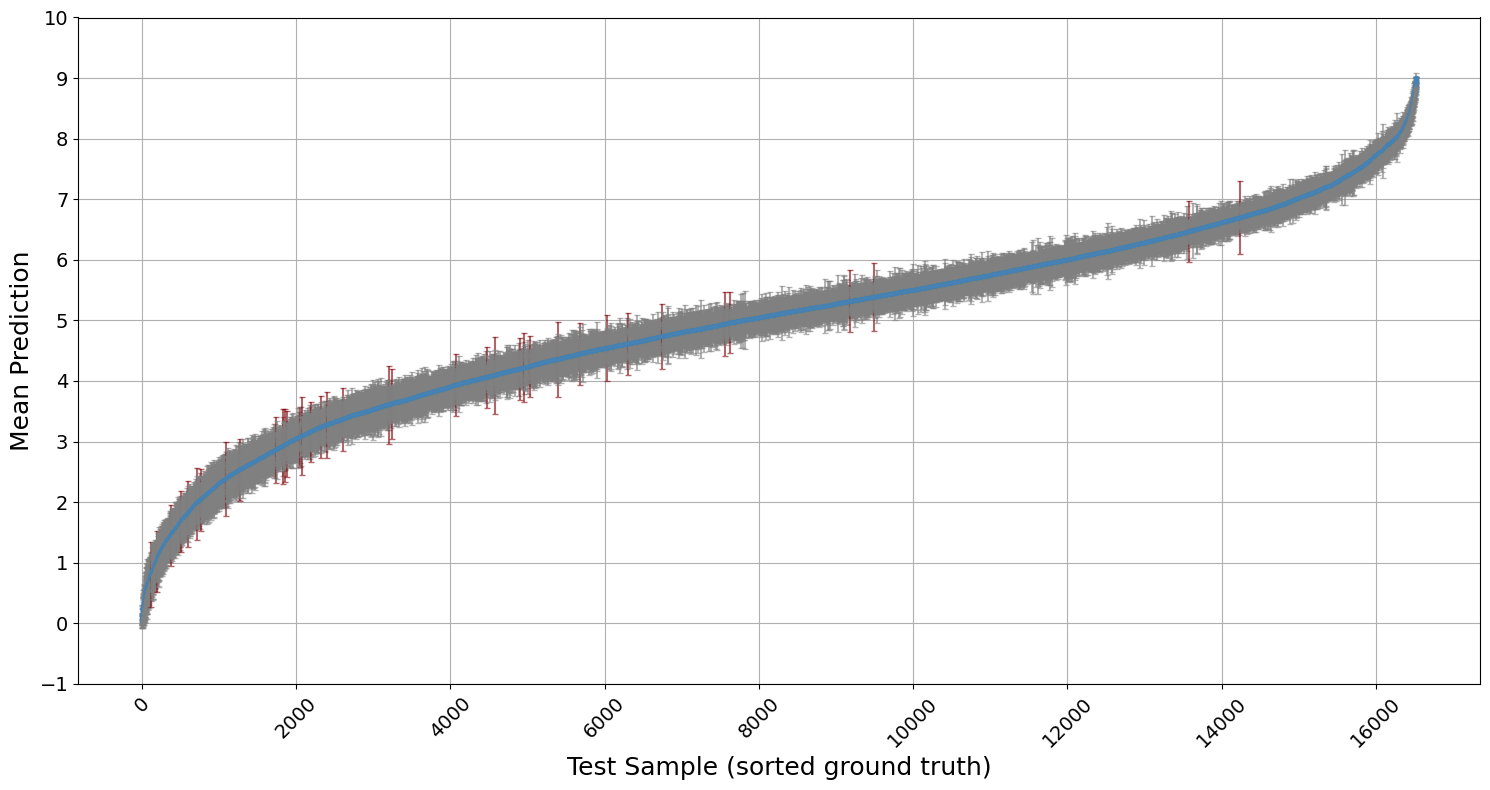

In [32]:
label_size = 18 
tick_size = 14
x_ticks_max = df_ensembles_sorted.shape[0]

plt.figure(figsize=(15, 8))

# Loop through each sample
for i in range(len(df_ensembles_sorted)):
    mean = df_ensembles_sorted['y_pred_mean'].iloc[i]
    std = df_ensembles_sorted['y_uncertainty'].iloc[i]
    
    err_color = '#7f0007' if std > 0.5 else 'gray'

    # Plot error bar only (no marker)
    plt.errorbar(
        x=i,
        y=mean,
        yerr=std,
        fmt='none',          # No marker
        ecolor=err_color,
        alpha=0.4 if err_color == 'grey' else 0.6,           # Alpha for error bars
        capsize=2
    )

    # Plot marker separately
    plt.plot(
        i,
        mean,
        'o',
        markersize=3,
        color='steelblue',       # Marker color
        alpha=1           # Alpha for marker
    )

plt.xlabel("Test Sample (sorted ground truth)", size=label_size)
plt.ylabel("Mean Prediction", size=label_size)
plt.yticks(np.arange(-1, 11, step=1), size=tick_size)
plt.xticks(np.arange(0, round(x_ticks_max * 1.05, -2), step=2000), size=tick_size)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
num_high_uncertainty = df_ensembles[df_ensembles['y_uncertainty'] >= 0.5].shape[0]
total_samples = df_ensembles.shape[0]
percentage_high_uncertainty = (num_high_uncertainty / total_samples) * 100
percentage_high_uncertainty

0.22998244870786178

In [34]:
print(f"Average Uncertainty of Predictions: {df_ensembles['y_uncertainty'].mean():.4f}")
print(f"High-risk Uncertainty of Predictions: {df_ensembles[df_ensembles['y_pred_mean'] >= 5]['y_uncertainty'].mean():.4f}")
print(f"Low-risk Uncertainty of Predictions: {df_ensembles[df_ensembles['y_pred_mean'] < 5]['y_uncertainty'].mean():.4f}")

Average Uncertainty of Predictions: 0.1973
High-risk Uncertainty of Predictions: 0.1711
Low-risk Uncertainty of Predictions: 0.2266


In [35]:
print(f"Average Std Dev of Predictions: {df_ensembles['y_uncertainty'].mean():.4f}")

print(f"Top 5 Most Uncertain Samples by Std Dev:\n{df_ensembles.sort_values(by='y_uncertainty', ascending=False).head()}")

Average Std Dev of Predictions: 0.1973
Top 5 Most Uncertain Samples by Std Dev:
          ens_1     ens_2     ens_3     ens_4     ens_5     ens_6     ens_7  \
15801  3.277158  2.925868  3.878985  2.852973  3.114172  4.177629  4.216694   
411    2.557067  2.663718  2.904828  3.794222  3.530483  1.919537  3.473199   
3512   4.369369  4.077882  4.666016  3.893752  4.544825  4.153736  3.253964   
1498   3.594681  5.084351  3.565549  5.336935  4.454575  4.902314  4.293601   
4984   2.793786  2.151551  2.943686  2.804135  3.836324  3.275596  3.075036   

          ens_8     ens_9    ens_10  y_true  y_pred_mean  y_uncertainty  \
15801  3.613804  4.810557  3.197366       6     3.606520       0.647378   
411    4.056684  3.057590  2.945587       1     3.090292       0.637982   
3512   3.033620  5.132670  3.820844       1     4.094668       0.635410   
1498   4.259377  4.404345  3.664000       0     4.355973       0.623588   
4984   3.833206  2.072116  2.372021       0     2.915745       0.62035